# Трек 1
Steihaug–Toint, доверительная область, ML без L2, модификации гессиана (`лаб2.pdf`, прил. А).


In [1]:
%load_ext autoreload
%autoreload 2


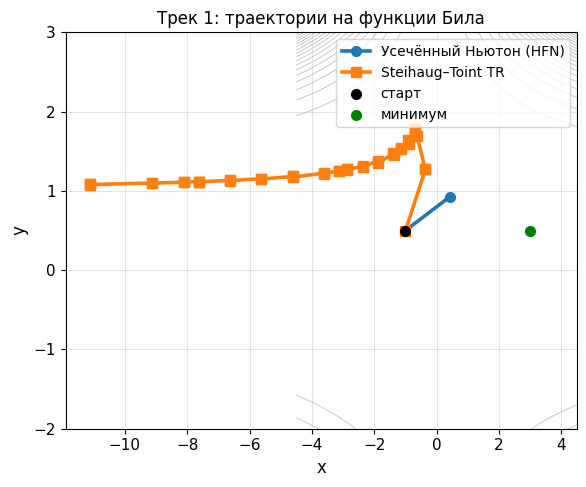

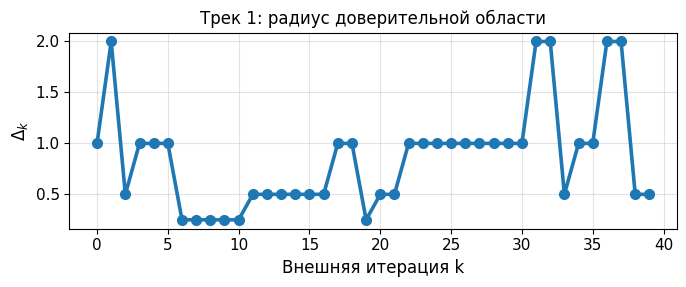

Track1 triazines lambda=0: success f= 1.007529045081063


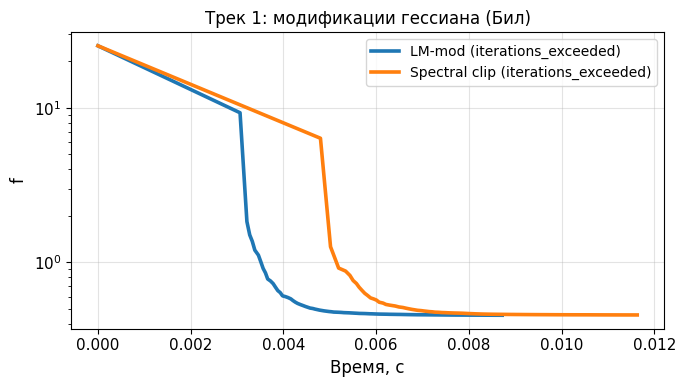

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

be = NonConvexOracle()
x0 = np.array([-1.0, 0.5])
line = {"method": "Wolfe", "alpha_0": 1.0}

_, _, h1 = hessian_free_newton(be, x0, tolerance=1e-6, line_search_options=line, trace=True)
_, _, h2 = trust_region_steihaug_newton(be, x0, tolerance=1e-6, trace=True, delta_0=1.0)

fig, ax = plt.subplots(figsize=(6, 5))
gx = np.linspace(-4.5, 4.5, 120)
gy = np.linspace(-2.0, 3.0, 120)
Gx, Gy = np.meshgrid(gx, gy)
Z = beale_mesh_Z(Gx, Gy)
ax.contour(Gx, Gy, Z, levels=25, colors="0.7", linewidths=0.6, alpha=0.85)
xs1 = np.array(h1["x"])
xs2 = np.array(h2["x"])
if xs1.size:
    ax.plot(xs1[:, 0], xs1[:, 1], "o-", label="Усечённый Ньютон (HFN)")
if xs2.size:
    ax.plot(xs2[:, 0], xs2[:, 1], "s-", label="Steihaug–Toint TR")
ax.scatter([x0[0]], [x0[1]], c="k", zorder=5, label="старт")
ax.scatter([3.0], [0.5], c="g", zorder=5, label="минимум")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Трек 1: траектории на функции Била")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp_t1_beale_traj")
plt.show()

if h2 and "delta" in h2:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(np.arange(len(h2["delta"])), h2["delta"], "o-")
    ax.set_xlabel("Внешняя итерация k")
    ax.set_ylabel(r"$\Delta_k$")
    ax.set_title("Трек 1: радиус доверительной области")
    fig.tight_layout()
    savefig_both(fig, "exp_t1_delta")
    plt.show()

Xr, yr = load_triazines()
oracle0 = make_regression_oracle(Xr, yr, 0.0)
x0r = np.zeros(Xr.shape[1])
x_opt, msg_tr, _ = trust_region_steihaug_newton(
    oracle0, x0r, tolerance=1e-4, max_iter=200, trace=False
)
print("Track1 triazines lambda=0:", msg_tr, "f=", float(oracle0.func(x_opt)))

x0b = np.array([-1.0, 0.5])
_, m_lm, h_lm = newton_modified(
    be, x0b, tolerance=1e-8, line_search_options=line, trace=True, hessian_mod="lm"
)
_, m_sp, h_sp = newton_modified(
    be,
    x0b,
    tolerance=1e-8,
    line_search_options=line,
    trace=True,
    hessian_mod="spectral",
    spectral_abs=False,
)
fig, ax = plt.subplots(figsize=(7, 4))
if h_lm:
    ax.semilogy(h_lm["time"], h_lm["func"], label="LM-mod ({})".format(m_lm))
if h_sp:
    ax.semilogy(h_sp["time"], h_sp["func"], label="Spectral clip ({})".format(m_sp))
ax.set_xlabel("Время, с")
ax.set_ylabel("f")
ax.set_title("Трек 1: модификации гессиана (Бил)")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp_t1_hessian_mod_beale")
plt.show()
